# Data Preprocessing Tools

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('Data.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [3]:
print(X)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 nan]
 ['France' 35.0 58000.0]
 ['Spain' nan 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


In [4]:
print(y)

<StringArray>
['No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes']
Length: 10, dtype: str


## Taking care of missing data

In [5]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(X[:, 1:3])
X[:, 1:3] = imputer.transform(X[:, 1:3])

In [6]:
print(X)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 63777.77777777778]
 ['France' 35.0 58000.0]
 ['Spain' 38.77777777777778 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


## Encoding categorical data

### Encoding the Independent Variable

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [8]:
print(X)

[[1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [0.0 1.0 0.0 30.0 54000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [1.0 0.0 0.0 35.0 58000.0]
 [0.0 0.0 1.0 38.77777777777778 52000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


### Encoding the Dependent Variable

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [10]:
print(y)

[0 1 0 0 1 1 0 1 0 1]


## Splitting the dataset into the Training set and Test set

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [12]:
print(X_train)

[[0.0 0.0 1.0 38.77777777777778 52000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 35.0 58000.0]]


In [13]:
print(X_test)

[[0.0 1.0 0.0 30.0 54000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


In [14]:
print(y_train)

[0 1 0 0 1 1 0 1]


In [15]:
print(y_test)

[0 1]


## Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [17]:
print(X_train)

[[-0.77459667 -0.57735027  1.29099445 -0.19159184 -1.07812594]
 [-0.77459667  1.73205081 -0.77459667 -0.01411729 -0.07013168]
 [ 1.29099445 -0.57735027 -0.77459667  0.56670851  0.63356243]
 [-0.77459667 -0.57735027  1.29099445 -0.30453019 -0.30786617]
 [-0.77459667 -0.57735027  1.29099445 -1.90180114 -1.42046362]
 [ 1.29099445 -0.57735027 -0.77459667  1.14753431  1.23265336]
 [-0.77459667  1.73205081 -0.77459667  1.43794721  1.57499104]
 [ 1.29099445 -0.57735027 -0.77459667 -0.74014954 -0.56461943]]


In [18]:
print(X_test)

[[-0.77459667  1.73205081 -0.77459667 -1.46618179 -0.9069571 ]
 [ 1.29099445 -0.57735027 -0.77459667 -0.44973664  0.20564034]]


✅ Numpy version: 2.4.1
✅ Pandas version: 3.0.0
✅ Scikit-Learn: Sukses memuat LinearRegression
✅ Matplotlib: Menampilkan grafik di bawah...


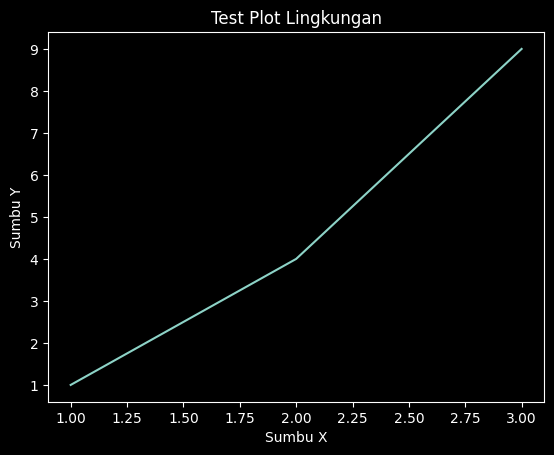

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Cek Versi (memastikan library terinstall)
print("✅ Numpy version:", np.__version__)
print("✅ Pandas version:", pd.__version__)

# 2. Cek Scikit-Learn (membuat model dummy)
try:
    model = LinearRegression()
    print("✅ Scikit-Learn: Sukses memuat LinearRegression")
except Exception as e:
    print("❌ Scikit-Learn Error:", e)

# 3. Cek Matplotlib (membuat grafik sederhana)
print("✅ Matplotlib: Menampilkan grafik di bawah...")
plt.plot([1, 2, 3], [1, 4, 9])
plt.title("Test Plot Lingkungan")
plt.xlabel("Sumbu X")
plt.ylabel("Sumbu Y")
plt.show()

In [20]:
import tensorflow as tf
import os

# 1. Cek Versi TensorFlow
print("✅ TensorFlow Version:", tf.__version__)

# 2. Cek Perhitungan Tensor Sederhana (Memastikan core engine berjalan)
try:
    a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
    b = tf.constant([[1.0, 1.0], [0.0, 1.0]])
    c = tf.matmul(a, b) # Perkalian Matriks
    print("✅ Tes Perhitungan Matriks: SUKSES")
    print("   Hasil:\n", c.numpy())
except Exception as e:
    print("❌ Error Perhitungan:", e)

# 3. Cek Hardware (CPU vs GPU)
print("\n--- Cek Hardware ---")
gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')

print(f"Jumlah CPU terdeteksi: {len(cpus)}")
print(f"Jumlah GPU terdeteksi: {len(gpus)}")

if len(gpus) > 0:
    print("🚀 Mantap! TensorFlow menggunakan GPU (Pelatihan akan lebih cepat).")
else:
    print("⚠️ TensorFlow menggunakan CPU.")
    print("   (Tidak masalah untuk pembelajaran awal, tapi mungkin agak lambat untuk Deep Learning berat).")

✅ TensorFlow Version: 2.20.0
✅ Tes Perhitungan Matriks: SUKSES
   Hasil:
 [[1. 3.]
 [3. 7.]]

--- Cek Hardware ---
Jumlah CPU terdeteksi: 1
Jumlah GPU terdeteksi: 0
⚠️ TensorFlow menggunakan CPU.
   (Tidak masalah untuk pembelajaran awal, tapi mungkin agak lambat untuk Deep Learning berat).
